# 05 — Tag transactions

Tag each sales row with is_promo (promo_cal match), is_markdown (price < threshold × SKU median), is_stockout_week (inv=0 that week OR shipped < customer typical weekly).

**Upstream:** sales_with_brand.parquet, promo_cal.parquet, inv_weekly.parquet

**Output:** sales_tagged.parquet

**Promotes to:** `src/tagging.py` once verified.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Tunable thresholds — passed to src.tagging.tag_transactions
MARKDOWN_FACTOR     = 0.85   # price < 0.85 * (SKU × channel) median -> is_markdown
                             # Calibrated to the demand-response curve: rows
                             # 10-20% below median show 2.6x normal qty, 20-30%
                             # below show 4x, 30%+ show 11x. 0.85 picks up the
                             # first meaningful bump. See 05b experiment.
MARKDOWN_MIN_N      = 5      # min rows per (SKU × channel) to trust the
                             # per-channel median; below that fall back to
                             # pooled SKU median.
LOST_DEMAND_COVER_K = 10.0   # low_stock if week_on_hand < K * typical weekly base sales
LOST_DEMAND_ORDER_F = 0.70   # cust shorted if order < F * customer median base qty for SKU
LOST_DEMAND_MIN_N   = 3      # min orders per (customer, SKU) to trust the customer median


## 2. Load upstream

In [2]:
from src.channel import attach_channel

sales      = pd.read_parquet(ART / 'sales_with_brand.parquet')
promo_cal  = pd.read_parquet(ART / 'promo_cal.parquet')
inv_weekly = pd.read_parquet(ART / 'inv_weekly.parquet')
slprsn_key = pd.read_parquet(ART / 'slprsn_key.parquet')

# promo_cal.promo_ym was stringified on save; round-trip back to Period[M].
promo_cal['promo_ym'] = pd.PeriodIndex(promo_cal['promo_ym'], freq='M')

# Attach SALESCHANNEL now so markdown detection can use per-(SKU × channel) median.
# Must run BEFORE tag_transactions() since tag_markdown needs the channel column.
sales = attach_channel(sales, slprsn_key)

print(f'sales      : {sales.shape}   cols={list(sales.columns)[:8]}...')
print(f'promo_cal  : {promo_cal.shape}')
print(f'inv_weekly : {inv_weekly.shape}  confidence={inv_weekly["confidence"].value_counts().to_dict()}')
print(f'slprsn_key : {slprsn_key.shape}  channel mix in sales: '
      f'{sales["SALESCHANNEL"].value_counts(dropna=False).to_dict()}')


sales      : (236818, 26)   cols=['LOCNCODE', 'SLPRSNID', 'CUSTNMBR', 'CITY', 'STATE', 'ZIPCODE', 'SOP TYPE', 'SOPNUMBE']...
promo_cal  : (1134, 3)
inv_weekly : (37887, 5)  confidence={'high': 33043, 'low': 4844}
slprsn_key : (46, 3)  channel mix in sales: {'MM': 113226, 'AM': 107399, 'HF': 16189, nan: 4}


## 3. Do the work

In [3]:
from src.tagging import tag_transactions

sales, meta = tag_transactions(
    sales, promo_cal, inv_weekly,
    markdown_factor=MARKDOWN_FACTOR,
    markdown_min_n=MARKDOWN_MIN_N,
    lost_demand_cover_k=LOST_DEMAND_COVER_K,
    lost_demand_order_f=LOST_DEMAND_ORDER_F,
    lost_demand_min_n=LOST_DEMAND_MIN_N,
)

# ---- Summary ---------------------------------------------------------------
n = meta['n_rows']
def _pct(k): return meta[k] / n * 100

print(f'total sales rows                 : {n:,}')
print(f'is_promo             : {meta["is_promo_true"]:>8,} ({_pct("is_promo_true"):5.1f}%)')
print(f'is_markdown          : {meta["is_markdown_true"]:>8,} ({_pct("is_markdown_true"):5.1f}%)  (factor={MARKDOWN_FACTOR}, per-(SKU × channel) median)')
print(f'is_stockout_week     : {meta["is_stockout_week_true"]:>8,} ({_pct("is_stockout_week_true"):5.1f}%)  (strict: on_hand<=0)')
print(f'is_lost_demand_week  : {meta["is_lost_demand_week_true"]:>8,} ({_pct("is_lost_demand_week_true"):5.1f}%)  (low stock AND cust below normal)')
print(f'   low_stock_week          : {meta["low_stock_week_true"]:>8,} ({_pct("low_stock_week_true"):5.1f}%)')
print(f'   cust_below_normal       : {meta["cust_below_normal_true"]:>8,} ({_pct("cust_below_normal_true"):5.1f}%)')
print(f'   lost_demand NA (no inv or no cust baseline) : {meta["is_lost_demand_week_na"]:,}')
print(f'is_clean_demand      : {meta["is_clean_demand_true"]:>8,} ({_pct("is_clean_demand_true"):5.1f}%)')

print('\nflag overlap (is_promo × is_markdown):')
print(pd.crosstab(sales['is_promo'], sales['is_markdown']).to_string())

print('\nis_markdown per channel:')
print(sales.groupby('SALESCHANNEL', dropna=False).agg(
    n=('is_markdown', 'size'),
    flagged=('is_markdown', 'sum'),
).assign(pct=lambda d: 100 * d['flagged'] / d['n']).round(2).to_string())

print('\nlost-demand-week overlap with other flags:')
ld = sales['is_lost_demand_week'] == True
print(f'   and is_promo        : {(ld & sales["is_promo"]).sum():,}')
print(f'   and is_markdown     : {(ld & sales["is_markdown"]).sum():,}')
print(f'   and is_stockout_week: {(ld & (sales["is_stockout_week"]==True)).sum():,}')


total sales rows                 : 236,818
is_promo             :   24,078 ( 10.2%)
is_markdown          :   31,256 ( 13.2%)  (factor=0.85, per-(SKU × channel) median)
is_stockout_week     :       98 (  0.0%)  (strict: on_hand<=0)
is_lost_demand_week  :      551 (  0.2%)  (low stock AND cust below normal)
   low_stock_week          :    2,517 (  1.1%)
   cust_below_normal       :   48,548 ( 20.5%)
   lost_demand NA (no inv or no cust baseline) : 38,817
is_clean_demand      :  182,803 ( 77.2%)

flag overlap (is_promo × is_markdown):
is_markdown   False  True 
is_promo                  
False        183237  29503
True          22325   1753

is_markdown per channel:
                   n  flagged    pct
SALESCHANNEL                        
AM            107399    14947  13.92
HF             16189     1309   8.09
MM            113226    15000  13.25
NaN                4        0   0.00

lost-demand-week overlap with other flags:
   and is_promo        : 147
   and is_markdown     : 13
   an

## 4. Validate

row count preserved: 236,818
is_promo nulls            : 0
is_markdown nulls         : 0
is_stockout_week nulls    : 30,563  (rows without inv_weekly coverage)
is_lost_demand_week nulls : 38,817  (no inv or no cust baseline)

Markdown depth (price / markdown_denom, i.e. per-channel median):
count    31256.000000
mean         0.749431
std          0.110932
min          0.030003
25%          0.718904
50%          0.789938
75%          0.826528
max          0.849992


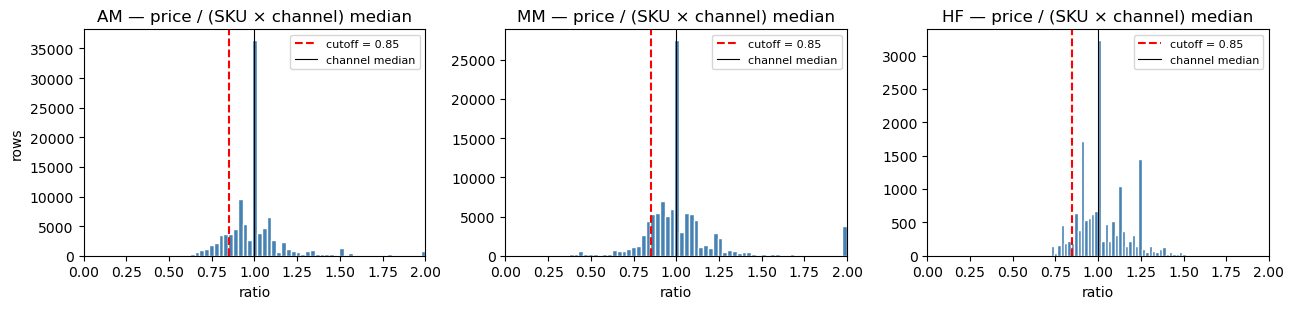


is_promo rows by brand:
brand
tiger balm     18914
ginger chew     5078
am gsg            86

--- LD.1 magnitude ---
is_lost_demand_week TRUE  : 551 (0.23% of all rows)
    of rows with non-NA flag : 0.28%

by brand (top):
brand
tiger balm     289
ferrero        114
ginger chew     76
am gsg          38
pop tea         23
totole          10
mx eggrolls      1

by DC:
DC
NJ    269
SF    209
LA     73

by SKU (top 10):
ITEMNMBR
T-32206    277
F-12418     43
A-61117     34
F-12402     29
F-20141     26
F-04114     24
F-04220     19
F-04221     15
F-12122     14
D-15206     13

--- LD.2 timing cluster: T-32206 SF ---
T-32206 SF: 157 weeks, 145 flagged rows across 12 weeks
top 10 flagged weeks:
week_start  flagged  rows  low_stock  on_hand
2023-07-24       26    51         51  36162.0
2023-05-22       22    37         37   6293.0
2023-05-29       16    22         22  -1495.0
2023-06-19       13    28         28 -17450.0
2023-06-05       12    24         24  -5167.0
2023-06-26       11    3

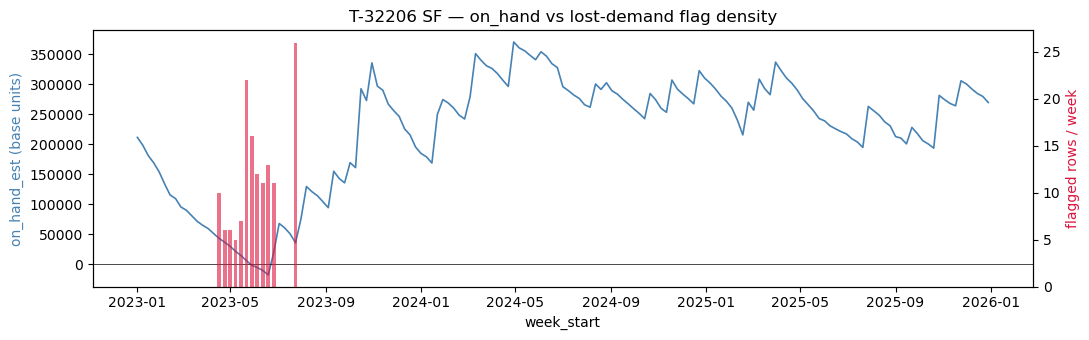


--- LD.3 DC substitution (flagged week -> other DC above cust median) ---
flagged (cust,sku,week) events : 335
   with another DC shipping same week  : 98
   that other DC shipped > cust median : 74
   substitution rate : 75.5%

--- LD.4 backfill signal (next order within 12w above cust median?) ---
flagged rows with next-order within 12w : 416
   next order > cust median : 114  (27.4%)
   baseline (cust_below_normal w/ no inv dip) : 29.1%  (n=42,166)

--- LD.5 spot check: T-32206 SF deepest-dip window ---
deepest week : 2023-06-19  (window ±4w)


week_start  rows  on_hand  typical  low_stock  lost_demand  cust_short
2023-05-22    37   6293.0   4718.0         37           22          22
2023-05-29    22  -1495.0   4718.0         22           16          16
2023-06-05    24  -5167.0   4718.0         24           12          12
2023-06-12    24 -10034.0   4718.0         24           11          11
2023-06-19    28 -17450.0   4718.0         28           13          13
2023-06-26    30  20000.0   4718.0         30           11          11
2023-07-03    24  68268.0   4718.0          0            0          11
2023-07-10    33  61031.0   4718.0          0            0           7
2023-07-17    33  51054.0   4718.0          0            0           6


In [4]:
# ---- Check 1: shape + no row loss ------------------------------------------
sales_in = pd.read_parquet(ART / 'sales_with_brand.parquet')
assert len(sales) == len(sales_in), f'Row count changed! {len(sales_in)} -> {len(sales)}'
print(f'row count preserved: {len(sales):,}')

# ---- Check 2: null sanity on the 4 flags -----------------------------------
print(f'is_promo nulls            : {sales["is_promo"].isna().sum()}')
print(f'is_markdown nulls         : {sales["is_markdown"].isna().sum()}')
print(f'is_stockout_week nulls    : {sales["is_stockout_week"].isna().sum():,}  (rows without inv_weekly coverage)')
print(f'is_lost_demand_week nulls : {sales["is_lost_demand_week"].isna().sum():,}  (no inv or no cust baseline)')

# ---- Check 3: markdown depth distribution ----------------------------------
# markdown_denom is the per-(SKU × channel) median (fallback: pooled SKU median).
md = sales[sales['is_markdown'] & sales['markdown_denom'].notna()].copy()
md['price_ratio'] = md['Unit_Price_adj'] / md['markdown_denom']
print(f'\nMarkdown depth (price / markdown_denom, i.e. per-channel median):')
print(md['price_ratio'].describe().to_string())

# Per-channel histogram — shows how the cutoff lands within each channel's
# own price distribution, which is the whole point of per-channel medians.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=False)
for ax, chan in zip(axes, ['AM', 'MM', 'HF']):
    mask = (sales['SALESCHANNEL'] == chan) & (sales['Unit_Price_adj'] > 0) & sales['markdown_denom'].notna()
    r = (sales.loc[mask, 'Unit_Price_adj'] / sales.loc[mask, 'markdown_denom']).clip(0, 2)
    ax.hist(r, bins=70, color='steelblue', edgecolor='white')
    ax.axvline(MARKDOWN_FACTOR, color='red', linestyle='--',
               label=f'cutoff = {MARKDOWN_FACTOR}')
    ax.axvline(1.0, color='black', linestyle='-', lw=0.8, label='channel median')
    ax.set_title(f'{chan} — price / (SKU × channel) median')
    ax.set_xlim(0, 2)
    ax.set_xlabel('ratio')
    ax.legend(fontsize=8)
axes[0].set_ylabel('rows')
plt.tight_layout()
plt.show()

# ---- Check 4: is_promo brand mix -------------------------------------------
print('\nis_promo rows by brand:')
print(sales[sales['is_promo']].groupby('brand').size().sort_values(ascending=False).to_string())

# ===========================================================================
# Lost-demand validation (5 checks)
# ===========================================================================
ld = sales['is_lost_demand_week'] == True

# ---- LD.1: magnitude sanity overall + by brand + by DC ---------------------
print('\n--- LD.1 magnitude ---')
print(f'is_lost_demand_week TRUE  : {ld.sum():,} ({ld.mean()*100:.2f}% of all rows)')
den = (sales['is_lost_demand_week'].notna()).sum()
print(f'    of rows with non-NA flag : {ld.sum() / max(den,1) * 100:.2f}%')
print('\nby brand (top):')
print(sales[ld].groupby('brand').size().sort_values(ascending=False).head(10).to_string())
print('\nby DC:')
print(sales[ld].groupby('DC').size().sort_values(ascending=False).to_string())
print('\nby SKU (top 10):')
print(sales[ld].groupby('ITEMNMBR').size().sort_values(ascending=False).head(10).to_string())

# ---- LD.2: timing cluster for T-32206 SF -----------------------------------
# If the detector works, flagged-row density should spike in the weeks where
# week_on_hand is lowest. Plot weekly flagged count against weekly on_hand.
print('\n--- LD.2 timing cluster: T-32206 SF ---')
sku_t, dc_t = 'T-32206', 'SF'
sub = sales[(sales['ITEMNMBR'] == sku_t) & (sales['DC'] == dc_t)].copy()
wk = sub.groupby('week_start').agg(
    flagged=('is_lost_demand_week', lambda s: (s == True).sum()),
    rows=('is_lost_demand_week', 'size'),
    low_stock=('low_stock_week', lambda s: (s == True).sum()),
    on_hand=('week_on_hand', 'first'),
).reset_index()
print(f'{sku_t} {dc_t}: {len(wk)} weeks, {wk["flagged"].sum()} flagged rows across {int((wk["flagged"]>0).sum())} weeks')
print('top 10 flagged weeks:')
print(wk.sort_values('flagged', ascending=False).head(10).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(11, 3.5))
ax1.plot(wk['week_start'], wk['on_hand'], color='steelblue', lw=1.2, label='on_hand_est')
ax1.axhline(0, color='black', lw=0.5)
ax1.set_ylabel('on_hand_est (base units)', color='steelblue')
ax1.set_xlabel('week_start')
ax2 = ax1.twinx()
ax2.bar(wk['week_start'], wk['flagged'], width=5, color='crimson', alpha=0.6,
        label='lost-demand rows')
ax2.set_ylabel('flagged rows / week', color='crimson')
ax1.set_title(f'{sku_t} {dc_t} — on_hand vs lost-demand flag density')
plt.tight_layout()
plt.show()

# ---- LD.3: DC substitution -------------------------------------------------
# When one DC is flagged for a (customer, SKU, week), do other DCs show
# above-normal shipments (customer sourced from a non-stocked-out DC)?
print('\n--- LD.3 DC substitution (flagged week -> other DC above cust median) ---')
flagged_keys = sales.loc[ld, ['CUSTNMBR', 'ITEMNMBR', 'week_start', 'DC']].copy()
if len(flagged_keys):
    merged = flagged_keys.merge(
        sales[['CUSTNMBR', 'ITEMNMBR', 'week_start', 'DC', 'QTY_BASE', 'cust_median_qty']],
        on=['CUSTNMBR', 'ITEMNMBR', 'week_start'], how='left', suffixes=('_flagged', '_any'),
    )
    other = merged[merged['DC_any'] != merged['DC_flagged']].copy()
    other['above_normal'] = (
        other['cust_median_qty'].notna()
        & (other['QTY_BASE'] > other['cust_median_qty'])
    )
    n_flag_events = flagged_keys.groupby(['CUSTNMBR', 'ITEMNMBR', 'week_start']).ngroups
    n_with_other  = other.groupby(['CUSTNMBR', 'ITEMNMBR', 'week_start']).ngroups
    n_substituted = (other.groupby(['CUSTNMBR', 'ITEMNMBR', 'week_start'])['above_normal']
                     .any().sum())
    print(f'flagged (cust,sku,week) events : {n_flag_events:,}')
    print(f'   with another DC shipping same week  : {n_with_other:,}')
    print(f'   that other DC shipped > cust median : {n_substituted:,}')
    if n_with_other:
        print(f'   substitution rate : {n_substituted / n_with_other * 100:.1f}%')
else:
    print('(no flagged rows)')

# ---- LD.4: backfill signal -------------------------------------------------
# If a customer was shorted, do they come back and order above-normal soon
# after? Look at same (cust, sku) next order within 12 weeks.
print('\n--- LD.4 backfill signal (next order within 12w above cust median?) ---')
sales = sales.sort_values(['CUSTNMBR', 'ITEMNMBR', 'DOCDATE']).reset_index(drop=True)
ld = sales['is_lost_demand_week'] == True  # recompute after re-sort
gb = sales.groupby(['CUSTNMBR', 'ITEMNMBR'])
sales['_next_qty']  = gb['QTY_BASE'].shift(-1)
sales['_next_date'] = gb['DOCDATE'].shift(-1)
sales['_days_to_next'] = (sales['_next_date'] - sales['DOCDATE']).dt.days
bf_mask = ld & sales['cust_median_qty'].notna() & sales['_days_to_next'].le(84)
bf = sales.loc[bf_mask].copy()
if len(bf):
    bf['next_above_normal'] = bf['_next_qty'] > bf['cust_median_qty']
    print(f'flagged rows with next-order within 12w : {len(bf):,}')
    print(f'   next order > cust median : {bf["next_above_normal"].sum():,}  ({bf["next_above_normal"].mean()*100:.1f}%)')
    # Baseline: cust_below_normal but NOT lost-demand (no inv dip)
    base_mask = ((~ld) & sales['cust_below_normal']
                 & sales['cust_median_qty'].notna()
                 & sales['_days_to_next'].le(84))
    base = sales.loc[base_mask]
    if len(base):
        base_rate = (base['_next_qty'] > base['cust_median_qty']).mean() * 100
        print(f'   baseline (cust_below_normal w/ no inv dip) : {base_rate:.1f}%  (n={len(base):,})')
else:
    print('(no flagged rows with a next-order window)')
sales = sales.drop(columns=['_next_qty', '_next_date', '_days_to_next'])

# ---- LD.5: spot-check the known-bad T-32206 SF window ----------------------
# Step 04 saw T-32206 SF min on_hand ~ -17,450. The weeks near that trough
# should be densely flagged (or at least have low_stock_week).
print('\n--- LD.5 spot check: T-32206 SF deepest-dip window ---')
sf = sales[(sales['ITEMNMBR'] == 'T-32206') & (sales['DC'] == 'SF')].copy()
if len(sf) and sf['week_on_hand'].notna().any():
    trough_week = sf.loc[sf['week_on_hand'].idxmin(), 'week_start']
    win_start = trough_week - pd.Timedelta(weeks=4)
    win_end   = trough_week + pd.Timedelta(weeks=4)
    w = sf[(sf['week_start'] >= win_start) & (sf['week_start'] <= win_end)]
    print(f'deepest week : {trough_week.date()}  (window ±4w)')
    summary = w.groupby('week_start').agg(
        rows=('QTY_BASE', 'size'),
        on_hand=('week_on_hand', 'first'),
        typical=('typical_weekly_base', 'first'),
        low_stock=('low_stock_week', lambda s: (s == True).sum()),
        lost_demand=('is_lost_demand_week', lambda s: (s == True).sum()),
        cust_short=('cust_below_normal', 'sum'),
    ).reset_index()
    print(summary.to_string(index=False))


## 5. Save downstream artifact

In [5]:
# Cast nullable-boolean flags to proper pandas 'boolean' dtype so parquet is happy.
for col in ('is_stockout_week', 'low_stock_week', 'is_lost_demand_week'):
    sales[col] = sales[col].astype('boolean')

sales.to_parquet(ART / 'sales_tagged.parquet')
print(f'sales_tagged  {sales.shape}  -> sales_tagged.parquet')
print(f'columns: {list(sales.columns)}')


sales_tagged  (236818, 44)  -> sales_tagged.parquet
columns: ['LOCNCODE', 'SLPRSNID', 'CUSTNMBR', 'CITY', 'STATE', 'ZIPCODE', 'SOP TYPE', 'SOPNUMBE', 'DOCDATE', 'ITEMNMBR', 'ITEMDESC', 'QUANTITY_adj', 'UOFM', 'QTYBSUOM', 'XTNDPRCE_adj', 'EXTDCOST_adj', 'Customer Type', 'Product Type', 'Source_File', 'Gross_Profit_adj', 'Margin_Pct_adj', 'UOM_Price', 'Unit_Price_adj', 'brand', 'SALESCHANNEL', 'SALESCHANNEL_DESC', 'sale_ym', 'DC', 'week_start', 'QTY_BASE', 'is_promo', 'sku_median_price', 'markdown_denom', 'markdown_threshold', 'is_markdown', 'week_on_hand', 'inv_confidence', 'is_stockout_week', 'typical_weekly_base', 'low_stock_week', 'cust_median_qty', 'cust_below_normal', 'is_lost_demand_week', 'is_clean_demand']


## 6. Promote

Done — logic lives in `src/tagging.py`. Public API: `tag_transactions(sales, promo_cal, inv_weekly, *, markdown_factor, lost_demand_cover_k, lost_demand_order_f, lost_demand_min_n) -> (sales_tagged, meta)`. Helpers: `tag_promo`, `tag_markdown`, `tag_stockout_week`, `tag_lost_demand_week`. Downstream steps (06_clean_demand) should import from there.